In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
np.random.seed(1)

In [2]:
def straight_line(x, m, c):
    return m * x + c

In [3]:
x = np.linspace(1, 9, 5)
x

array([1., 3., 5., 7., 9.])

In [4]:
y = straight_line(x, 3, 1) + np.random.randn(5) * 0.7

In [5]:
dy = (4 - 3) * np.random.random_sample(5) + 3

In [6]:
y, dy

(array([ 5.13704175,  9.57177051, 15.63027977, 21.24892196, 28.60578534]),
 array([3.41919451, 3.6852195 , 3.20445225, 3.87811744, 3.02738759]))

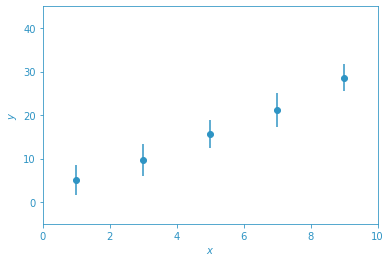

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.errorbar(x, y, dy, marker='o', ls='', color='#2e94c4')
ax.set_xlim(0, 10)
ax.set_ylim(-5, 45)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
#ax.set_facecolor('black')
ax.spines['bottom'].set_color('#2e94c4')
ax.spines['top'].set_color('#2e94c4') 
ax.spines['right'].set_color('#2e94c4')
ax.spines['left'].set_color('#2e94c4')
ax.tick_params(axis='x', colors='#2e94c4')
ax.tick_params(axis='y', colors='#2e94c4')
ax.yaxis.label.set_color('#2e94c4')
ax.xaxis.label.set_color('#2e94c4')
fig.savefig('xy.png', transparent=True, dpi=600)

In [8]:
from scipy.optimize import curve_fit

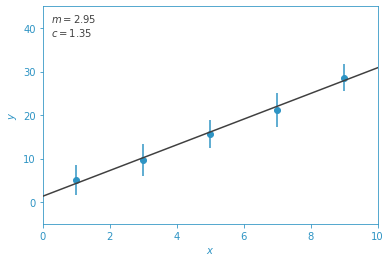

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
m, c = curve_fit(straight_line, x, y, sigma=dy)[0]
ax.plot(xx, straight_line(xx, m, c), ls='-', color='#404040', zorder=10)
ax.text(0.025, 0.975, f'$m={m:.2f}$\n$c={c:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#404040')
ax.errorbar(x, y, dy, marker='o', ls='', color='#2e94c4')
ax.set_xlim(0, 10)
ax.set_ylim(-5, 45)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
#ax.set_facecolor('black')
ax.spines['bottom'].set_color('#2e94c4')
ax.spines['top'].set_color('#2e94c4') 
ax.spines['right'].set_color('#2e94c4')
ax.spines['left'].set_color('#2e94c4')
ax.tick_params(axis='x', colors='#2e94c4')
ax.tick_params(axis='y', colors='#2e94c4')
ax.yaxis.label.set_color('#2e94c4')
ax.xaxis.label.set_color('#2e94c4')
fig.savefig('linreg.png', transparent=True, dpi=600)

In [10]:
from uravu.relationship import Relationship

In [11]:
r = Relationship(straight_line, x, y, ordinate_error=dy)

In [12]:
r.max_likelihood('mini')

In [13]:
r.mcmc()

100%|██████████| 1000/1000 [00:22<00:00, 43.94it/s]


In [14]:
r.variables[0].samples.size

25000

In [15]:
choice = np.random.randint(r.variables[0].samples.size, size=1000)

In [16]:
mean = []
std = []
for i in r.variables:
    print(i.n, i.con_int[1]-i.n)

2.8957338380108326 1.0845791329508083
1.594280146515697 6.1033155643078665


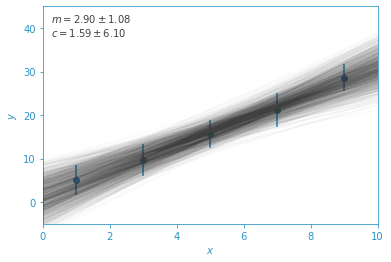

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
for i in choice:
    ax.plot(xx, straight_line(xx, *r.get_sample(i)), ls='-', color='#404040', alpha=0.02, zorder=10)
ax.errorbar(x, y, dy, marker='o', ls='', color='#2e94c4')
mean = []
std = []
for i in r.variables:
    mean.append(i.n)
    std.append(i.con_int[1]-i.n)
ax.text(0.025, 0.975, f'$m={mean[0]:.2f}\pm{std[0]:.2f}$\n$c={mean[1]:.2f}\pm{std[1]:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#404040')
ax.set_xlim(0, 10)
ax.set_ylim(-5, 45)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.spines['bottom'].set_color('#2e94c4')
ax.spines['top'].set_color('#2e94c4') 
ax.spines['right'].set_color('#2e94c4')
ax.spines['left'].set_color('#2e94c4')
ax.tick_params(axis='x', colors='#2e94c4')
ax.tick_params(axis='y', colors='#2e94c4')
ax.yaxis.label.set_color('#2e94c4')
ax.xaxis.label.set_color('#2e94c4')
fig.savefig('lines.png', transparent=True, dpi=600)

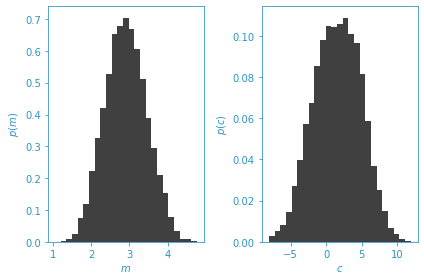

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=2)
l = ['m', 'c']
for i in [0, 1]:
    ax[i].hist(r.variables[i].samples, color='#404040', density=True, bins=25)
    ax[i].set_xlabel(f'${l[i]}$')
    ax[i].set_ylabel(f'$p({l[i]})$')
    #ax[i].set_facecolor('black')
    ax[i].spines['bottom'].set_color('#2e94c4')
    ax[i].spines['top'].set_color('#2e94c4') 
    ax[i].spines['right'].set_color('#2e94c4')
    ax[i].spines['left'].set_color('#2e94c4')
    ax[i].tick_params(axis='x', colors='#2e94c4')
    ax[i].tick_params(axis='y', colors='#2e94c4')
    ax[i].yaxis.label.set_color('#2e94c4')
    ax[i].xaxis.label.set_color('#2e94c4')
plt.tight_layout()
fig.savefig('post.png', transparent=True, dpi=600)

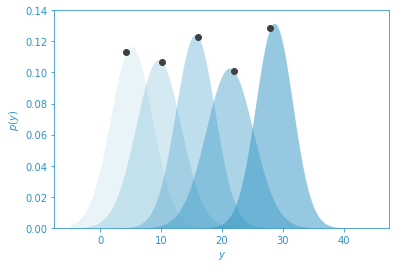

In [19]:
yy = np.linspace(-5, 45, 1000)
fig, ax = plt.subplots(nrows=1, ncols=1)
y_fit = straight_line(x, *curve_fit(straight_line, x, y, sigma=dy)[0])
for i, d in enumerate(y):
    #plt.plot(yy, norm(d, dy[i]).pdf(yy))
    ax.fill_between(yy, 0, norm(d, dy[i]).pdf(yy), alpha=(i + 1) * 0.1, color='#2e94c4', lw=0)
    ax.plot(y_fit[i], norm(d, dy[i]).pdf(y_fit[i]), marker='o', color='#404040')
plt.ylabel('$p(y)$')
plt.xlabel('$y$')
ax.set_ylim(0, 0.14)
ax.spines['bottom'].set_color('#2e94c4')
ax.spines['top'].set_color('#2e94c4') 
ax.spines['right'].set_color('#2e94c4')
ax.spines['left'].set_color('#2e94c4')
ax.tick_params(axis='x', colors='#2e94c4')
ax.tick_params(axis='y', colors='#2e94c4')
ax.yaxis.label.set_color('#2e94c4')
ax.xaxis.label.set_color('#2e94c4')
fig.savefig('pdfs.png', transparent=True, dpi=600)

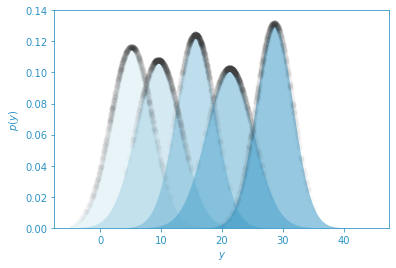

In [20]:
yy = np.linspace(-5, 45, 1000)
fig, ax = plt.subplots(nrows=1, ncols=1)
y_fit = straight_line(x, *curve_fit(straight_line, x, y, sigma=dy)[0])
for i, d in enumerate(y):
    ax.fill_between(yy, 0, norm(d, dy[i]).pdf(yy), alpha=(i + 1) * 0.1, color='#2e94c4', lw=0)
for j in choice:
    y_fit = straight_line(x, *r.get_sample(j))
    for i in range(len(y_fit)):
        ax.plot(y_fit[i], norm(y[i], dy[i]).pdf(y_fit[i]), marker='o', color='#404040', alpha=0.02, markeredgewidth=0)
plt.ylabel('$p(y)$')
plt.xlabel('$y$')
ax.set_ylim(0, 0.14)
ax.spines['bottom'].set_color('#2e94c4')
ax.spines['top'].set_color('#2e94c4') 
ax.spines['right'].set_color('#2e94c4')
ax.spines['left'].set_color('#2e94c4')
ax.tick_params(axis='x', colors='#2e94c4')
ax.tick_params(axis='y', colors='#2e94c4')
ax.yaxis.label.set_color('#2e94c4')
ax.xaxis.label.set_color('#2e94c4')
fig.savefig('pdfs_samp.png', transparent=True, dpi=600)

In [21]:
from scipy.stats import norm

In [22]:
norm.rvs(loc=3, scale=0, size=10)

array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.])

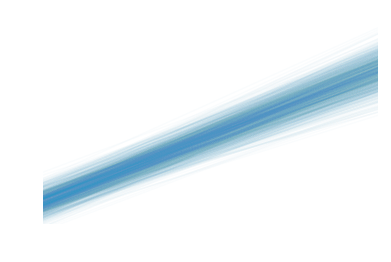

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
m, c = [norm(loc=3, scale=0.25), norm(loc=0, scale=2)]
mm = m.rvs(1000)
cc = c.rvs(1000)
for i in range(1000):
    ax.plot(xx, straight_line(xx, mm[i], cc[i]), ls='-', color='#2e94c4', zorder=10, alpha=0.02)
ax.text(0.025, 0.975, f'$m={np.mean(mm):.2f}\pm{np.std(mm):.2f}$\n$c={np.mean(cc):.2f}\pm{np.std(cc):.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#ffffff')
ax.errorbar(x, y, dy, marker='o', ls='', color='#ffffff')
ax.set_xlim(0, 10)
ax.set_ylim(-5, 45)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
#ax.set_facecolor('black')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('linregb.png', transparent=True, dpi=600)

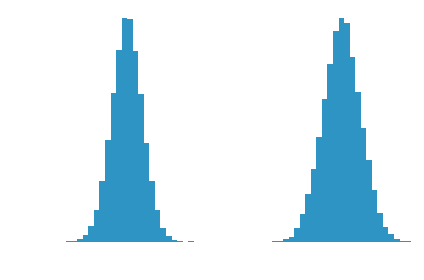

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=2)
l = ['m', 'c']
ll = [m, c]
for i in [0, 1]:
    ax[i].hist(ll[i].rvs(20000), color='#2e94c4', density=True, bins=25)
    ax[i].set_xlabel(f'${l[i]}$')
    ax[i].set_ylabel(f'$p({l[i]})$')
    #ax[i].set_facecolor('black')
    ax[i].spines['bottom'].set_color('#ffffff')
    ax[i].spines['top'].set_color('#ffffff') 
    ax[i].spines['right'].set_color('#ffffff')
    ax[i].spines['left'].set_color('#ffffff')
    ax[i].tick_params(axis='x', colors='#ffffff')
    ax[i].tick_params(axis='y', colors='#ffffff')
    ax[i].yaxis.label.set_color('#ffffff')
    ax[i].xaxis.label.set_color('#ffffff')
plt.tight_layout()
fig.savefig('prior.png', transparent=True, dpi=600)

In [25]:
def custom_prior():
    priors = []
    priors.append(m)
    priors.append(c)
    return priors

In [26]:
r2 = Relationship(straight_line, x, y, ordinate_error=dy)

In [27]:
r2.max_likelihood('mini')

In [28]:
r2.mcmc(prior_function=custom_prior)

100%|██████████| 1000/1000 [00:21<00:00, 47.49it/s]


In [29]:
for i in r.variables:
    print(i.n, np.std(i.samples))

2.8957338380108326 0.5452282107292352
1.594280146515697 3.312796669234567


In [30]:
for i in ll:
    print(i.stats()[1] ** 0.5)

0.25
2.0


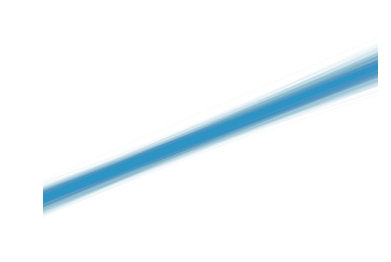

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
for i in choice:
    ax.plot(xx, straight_line(xx, *r2.get_sample(i)), ls='-', color='#2e94c4', alpha=0.02, zorder=10)
ax.errorbar(x, y, dy, marker='o', ls='', color='#ffffff')
mean = []
std = []
for i in r2.variables:
    mean.append(i.n)
    std.append(i.con_int[1]-i.n)
ax.text(0.025, 0.975, f'$m={mean[0]:.2f}\pm{std[0]:.2f}$\n$c={mean[1]:.2f}\pm{std[1]:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#ffffff')
ax.set_xlim(0, 10)
ax.set_ylim(-5, 45)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('linesb.png', transparent=True, dpi=600)

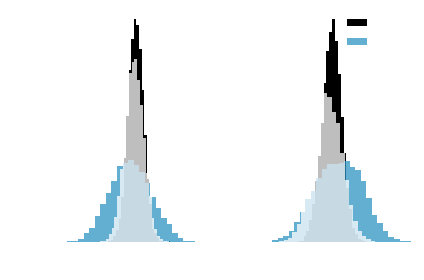

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2)
l = ['m', 'c']
for i in [0, 1]:
    ax[i].hist(r2.variables[i].samples, color='#000000', density=True, bins=25)
    ax[i].hist(r.variables[i].samples, color='#2e94c4', density=True, bins=25, alpha=0.75)
    ax[i].hist(ll[i].rvs(20000), color='#ffffff', density=True, bins=25, alpha=0.75)
    ax[i].set_xlabel(f'${l[i]}$')
    ax[i].set_ylabel(f'$p({l[i]})$')
    #ax[i].set_facecolor('black')
    ax[i].spines['bottom'].set_color('#ffffff')
    ax[i].spines['top'].set_color('#ffffff') 
    ax[i].spines['right'].set_color('#ffffff')
    ax[i].spines['left'].set_color('#ffffff')
    ax[i].tick_params(axis='x', colors='#ffffff')
    ax[i].tick_params(axis='y', colors='#ffffff')
    ax[i].yaxis.label.set_color('#ffffff')
    ax[i].xaxis.label.set_color('#ffffff')
leg = plt.legend(['$p(\mu|\mathbf{D})$', '$p(\mathbf{D}|\mu)$', '$p(\mu)$'], frameon=False)
for text in leg.get_texts():
    plt.setp(text, color = 'w')
plt.tight_layout()
fig.savefig('postb.png', transparent=True, dpi=600)

In [33]:
y2 = 2.5 * x ** 2 + 0.3 * x + 1.2 + np.random.randn(5) * y * 1.5

In [34]:
dy2 = dy * 7

<ErrorbarContainer object of 3 artists>

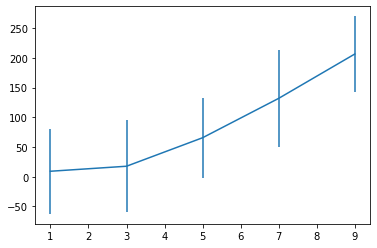

In [35]:
plt.errorbar(x, y2, dy2*3)

In [36]:
dy

array([3.41919451, 3.6852195 , 3.20445225, 3.87811744, 3.02738759])

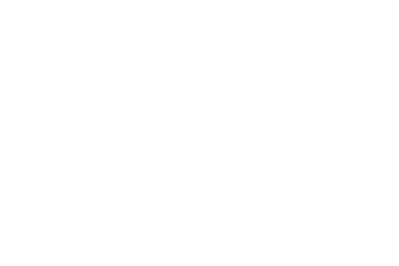

In [37]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
ax.errorbar(x, y2, dy2, marker='o', ls='', color='#ffffff')

ax.set_xlim(0, 10)
ax.set_ylim(-50, 250)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('quad.png', transparent=True, dpi=600)

In [38]:
r3 = Relationship(straight_line, x, y2, ordinate_error=dy2, bounds=((0, 200), (0, 200)))

In [39]:
r3.nested_sampling()

3764it [00:11, 318.30it/s, +500 | bound: 8 | nc: 1 | ncall: 23021 | eff(%): 18.522 | loglstar:   -inf < -23.547 <    inf | logz: -30.267 +/-  0.155 | dlogz:  0.001 >  0.509]


In [40]:
def quad(x, a, b, c):
    return a * x ** 2 + b * x + c

In [41]:
r4 = Relationship(quad, x, y2, ordinate_error=dy2)

In [42]:
r4.nested_sampling()

2339it [00:12, 187.20it/s, +500 | bound: 2 | nc: 1 | ncall: 19629 | eff(%): 14.463 | loglstar:   -inf < -20.967 <    inf | logz: -24.793 +/-  0.100 | dlogz:  0.001 >  0.509]


In [43]:
r4.ln_evidence

-24.792512348861298+/-0.09979391865058183

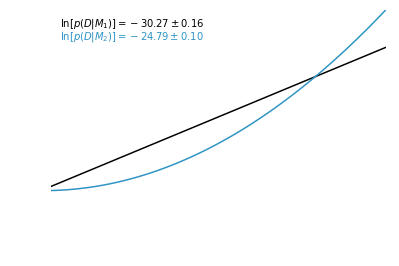

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
ax.plot(xx, straight_line(xx, *r3.variable_medians), ls='-', color='#000000', zorder=10)
ax.plot(xx, quad(xx, *r4.variable_medians), ls='-', color='#2e94c4', zorder=10)
ax.errorbar(x, y2, dy2, marker='o', ls='', color='#ffffff')

ax.set_xlim(0, 10)
ax.set_ylim(-50, 250)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.text(0.025, 0.975, f'$\ln[p(D|M_1)]={r3.ln_evidence.n:.2f}\pm{r3.ln_evidence.s:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#000000')
ax.text(0.025, 0.915, f'$\ln[p(D|M_2)]={r4.ln_evidence.n:.2f}\pm{r4.ln_evidence.s:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#2e94c4')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('nest.png', transparent=True, dpi=600)

In [45]:
r3.ln_evidence.n

-30.26686652073097

In [46]:
r5 = Relationship(straight_line, x, y2, ordinate_error=dy2*2, bounds=((0, 200), (0, 200)))

In [47]:
r5.nested_sampling()

2740it [00:11, 237.77it/s, +500 | bound: 4 | nc: 1 | ncall: 20459 | eff(%): 15.837 | loglstar:   -inf < -25.135 <    inf | logz: -29.817 +/-  0.122 | dlogz:  0.001 >  0.509]


In [48]:
r6 = Relationship(quad, x, y2, ordinate_error=dy2*2)

In [49]:
r6.nested_sampling()

1931it [00:12, 157.04it/s, +500 | bound: 1 | nc: 1 | ncall: 18119 | eff(%): 13.417 | loglstar:   -inf < -24.321 <    inf | logz: -27.312 +/-  0.077 | dlogz:  0.001 >  0.509]


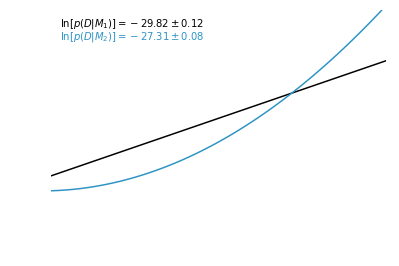

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=1)
xx = np.linspace(0, 10, 100)
ax.plot(xx, straight_line(xx, *r5.variable_medians), ls='-', color='#000000', zorder=10)
ax.plot(xx, quad(xx, *r6.variable_medians), ls='-', color='#2e94c4', zorder=10)
ax.errorbar(x, y2, dy2*2, marker='o', ls='', color='#ffffff')

ax.set_xlim(0, 10)
ax.set_ylim(-50, 250)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.text(0.025, 0.975, f'$\ln[p(D|M_1)]={r5.ln_evidence.n:.2f}\pm{r5.ln_evidence.s:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#000000')
ax.text(0.025, 0.915, f'$\ln[p(D|M_2)]={r6.ln_evidence.n:.2f}\pm{r6.ln_evidence.s:.2f}$', transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', color='#2e94c4')
ax.spines['bottom'].set_color('#ffffff')
ax.spines['top'].set_color('#ffffff') 
ax.spines['right'].set_color('#ffffff')
ax.spines['left'].set_color('#ffffff')
ax.tick_params(axis='x', colors='#ffffff')
ax.tick_params(axis='y', colors='#ffffff')
ax.yaxis.label.set_color('#ffffff')
ax.xaxis.label.set_color('#ffffff')
fig.savefig('nest2.png', transparent=True, dpi=600)

In [51]:
from uravu.utils import bayes_factor

In [52]:
k = f'{bayes_factor(r4.ln_evidence, r3.ln_evidence):.2f}'

In [53]:
k

'10.95+/-0.37'

In [54]:
f'{bayes_factor(r6.ln_evidence, r5.ln_evidence):.2f}'

'5.01+/-0.29'